In [1]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the Breast Cancer Dataset from Scikit-learn
data = load_breast_cancer()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target'] # 0 = Malignant, 1 = Benign

print("--- Step 1: Dataset Loaded Successfully ---")
print(f"Dataset Features Shape: {X.shape[0]} rows, {X.shape[1]} columns.\n")

--- Step 1: Dataset Loaded Successfully ---
Dataset Features Shape: 569 rows, 30 columns.



In [2]:
# 2. Split data into training and testing sets
# 80% Training data, 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("--- Step 2: Data Split Complete ---\n")

--- Step 2: Data Split Complete ---



In [3]:
# 3. Train a baseline Single Decision Tree (For Comparison)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

In [4]:
# 4. Train the Random Forest Ensemble Model
# Creating an ensemble of 100 trees to calculate votes
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

In [5]:
# 5. Evaluate and generate accuracy comparison report
print("--- Step 3 & 4: Performance Comparison ---")
print(f"Single Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print(f"Random Forest Ensemble Accuracy: {rf_accuracy * 100:.2f}%\n")

# Save the Comparison Report text file as requested in deliverables
with open("accuracy_comparison_report.txt", "w") as f:
    f.write("=== MODEL ACCURACY COMPARISON REPORT ===\n\n")
    f.write(f"Baseline Decision Tree Accuracy: {dt_accuracy * 100:.2f}%\n")
    f.write(f"Random Forest Ensemble Accuracy : {rf_accuracy * 100:.2f}%\n\n")
    f.write("=== RANDOM FOREST CLASSIFICATION DETAILS ===\n")
    f.write(classification_report(y_test, rf_pred, target_names=data['target_names']))
print("Success! 'accuracy_comparison_report.txt' saved locally.\n")

--- Step 3 & 4: Performance Comparison ---
Single Decision Tree Accuracy: 94.74%
Random Forest Ensemble Accuracy: 96.49%

Success! 'accuracy_comparison_report.txt' saved locally.



--- Step 5: Analyzing Feature Importance ---
Success! 'feature_importance_plot.png' saved locally.


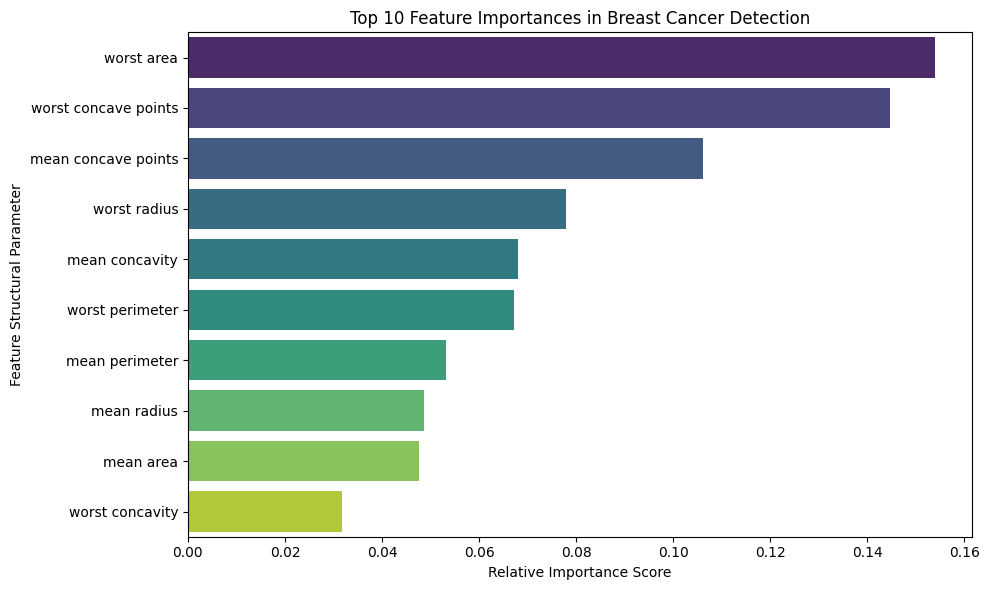

In [8]:
#6. Analyze and Plot Feature Importance
print("--- Step 5: Analyzing Feature Importance ---")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Take the top 10 most influential features for visibility
top_k = 10
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices[:top_k]], 
    y=X.columns[indices[:top_k]], 
    hue=X.columns[indices[:top_k]], 
    palette="viridis", 
    legend=False
)
plt.title('Top 10 Feature Importances in Breast Cancer Detection')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Structural Parameter')
plt.tight_layout()

# Save the visual graph asset
plt.savefig('feature_importance_plot.png', dpi=300)
print("Success! 'feature_importance_plot.png' saved locally.")
plt.show()